**Mattress Type Recommender System ด้วย Graph (Neo4j Aura)** <br>
แนวคิดคือ ผู้ใช้ดูหรือชอบประเภทที่นอนอะไร → หา User คนอื่นที่ชอบประเภทที่นอนคล้ายกัน → ดูว่าคนเหล่านั้นชอบประเภทที่นอนอะไรอีก → แนะนำประเภทที่นอนนั้นกลับมา

การออกแบบ Graph

```
Node มี 2 ประเภท (Label)

User
MattressType

Relationship คือ

PREFERS

(User)-[:PREFERS]->(MattressType)

เช่น

(Ben)-[:PREFERS]->(Spring Mattress)
```

In [ ]:
!pip install -q neo4j

In [ ]:
import neo4j

print("Neo4j Python Driver Version:", neo4j.__version__)

Neo4j Python Driver Version: 6.3.1


1.เริ่มติดต่อใช้งาน Neo4j online server (Neo4j Aura)

In [ ]:
from getpass import getpass
from neo4j import GraphDatabase

URI = "neo4j+s://6d0dd3db.databases.neo4j.io"
USERNAME = "6d0dd3db"
PASSWORD = getpass("Password: ")

driver = GraphDatabase.driver(
    URI,

    auth=(USERNAME, PASSWORD)
)

driver.verify_connectivity()

print("Connected successfully")

Password: ··········
Connected successfully


หา home database

In [ ]:
result = driver.execute_query(
    "SHOW HOME DATABASE"
)

for record in result.records:
    print(record.data())

{'name': '6d0dd3db', 'type': 'standard', 'aliases': [], 'access': 'read-write', 'address': 'p-mt-106bc5f59e02-6-0182.production-orch-0066.neo4j.io:7687', 'role': 'primary', 'writer': True, 'requestedStatus': 'online', 'currentStatus': 'online', 'statusMessage': '', 'constituents': []}


เก็บชื่อ database

In [ ]:
DATABASE = result.records[0]["name"]

print("Database =", DATABASE)

Database = 6d0dd3db


ทดสอบใช้งานฐานข้อมูล

In [ ]:
result = driver.execute_query(
    """
    MATCH (n)
    RETURN count(n) AS total_nodes
    """,
    database_=DATABASE
)

print("จำนวน Node =", result.records[0]["total_nodes"])

จำนวน Node = 0


2.ล้างข้อมูลเดิมของ User และ MattressType (ถ้ามี) เพื่อให้รันซ้ำได้ผลเหมือนเดิม

ลบเฉพาะ Node ที่มี Label `User` และ `MattressType` เท่านั้น ข้อมูลอื่น (เช่น Student, Book) จะไม่ถูกลบ

In [ ]:
driver.execute_query(
    """
    MATCH (n)

    WHERE n:User OR n:MattressType

    DETACH DELETE n
    """,
    database_=DATABASE
)

print("ล้างข้อมูล User และ MattressType แล้ว")

ล้างข้อมูล User และ MattressType แล้ว


3.สร้าง constraint ไม่ให้ชื่อซ้ำ

In [ ]:
driver.execute_query(
    """
    CREATE CONSTRAINT user_name_unique
    IF NOT EXISTS

    FOR (u:User)

    REQUIRE u.name IS UNIQUE
    """,
    database_=DATABASE
)

print("User constraint created")

User constraint created


In [ ]:
driver.execute_query(
    """
    CREATE CONSTRAINT mattress_type_name_unique
    IF NOT EXISTS

    FOR (m:MattressType)

    REQUIRE m.name IS UNIQUE
    """,
    database_=DATABASE
)

print("MattressType constraint created")

MattressType constraint created


4.เพิ่ม User

In [ ]:
users = [
    "Ben",
    "Jeff",
    "Mike",
    "Emma",
    "Daniel",
    "Alice",
    "Chris",
    "Sophia",
    "Liam",
    "Olivia"
]

In [ ]:
result = driver.execute_query(
    """
    UNWIND $users AS user_name

    MERGE (u:User {
        name: user_name
    })

    RETURN count(u) AS total
    """,

    users=users,
    database_=DATABASE
)

print(
    "จำนวน User ที่ประมวลผล =",
    result.records[0]["total"]
)

จำนวน User ที่ประมวลผล = 10


5.เพิ่ม MattressType

In [ ]:
mattress_types = [
    "Spring Mattress",
    "Memory Foam Mattress",
    "Latex Mattress",
    "Foam Mattress",
    "Pocket Spring Mattress",
    "Hybrid Mattress",
    "Air Mattress",
    "Waterbed Mattress",
    "Pillow Top Mattress",
    "Orthopedic Mattress"
]

In [ ]:
result = driver.execute_query(
    """
    UNWIND $mattress_types AS mattress_name

    MERGE (m:MattressType {
        name: mattress_name
    })

    RETURN count(m) AS total
    """,

    mattress_types=mattress_types,
    database_=DATABASE
)

print(
    "จำนวน MattressType ที่ประมวลผล =",
    result.records[0]["total"]
)

จำนวน MattressType ที่ประมวลผล = 10


6.สร้าง Relationship PREFERS

In [ ]:
preferences = [
    {"user": "Ben", "mattress_type": "Spring Mattress"},
    {"user": "Ben", "mattress_type": "Memory Foam Mattress"},

    {"user": "Jeff", "mattress_type": "Spring Mattress"},
    {"user": "Jeff", "mattress_type": "Memory Foam Mattress"},
    {"user": "Jeff", "mattress_type": "Foam Mattress"},

    {"user": "Mike", "mattress_type": "Spring Mattress"},
    {"user": "Mike", "mattress_type": "Latex Mattress"},

    {"user": "Emma", "mattress_type": "Foam Mattress"},
    {"user": "Emma", "mattress_type": "Pocket Spring Mattress"},

    {"user": "Daniel", "mattress_type": "Memory Foam Mattress"},
    {"user": "Daniel", "mattress_type": "Pocket Spring Mattress"},

    {"user": "Alice", "mattress_type": "Hybrid Mattress"},
    {"user": "Alice", "mattress_type": "Memory Foam Mattress"},

    {"user": "Chris", "mattress_type": "Air Mattress"},
    {"user": "Chris", "mattress_type": "Foam Mattress"},

    {"user": "Sophia", "mattress_type": "Waterbed Mattress"},
    {"user": "Sophia", "mattress_type": "Latex Mattress"},

    {"user": "Liam", "mattress_type": "Pillow Top Mattress"},
    {"user": "Liam", "mattress_type": "Spring Mattress"},

    {"user": "Olivia", "mattress_type": "Orthopedic Mattress"},
    {"user": "Olivia", "mattress_type": "Hybrid Mattress"}
]

In [ ]:
driver.execute_query(
    """
    UNWIND $preferences AS row

    MATCH
        (u:User {name: row.user}),
        (m:MattressType {name: row.mattress_type})

    MERGE
        (u)-[:PREFERS]->(m)
    """,

    preferences=preferences,
    database_=DATABASE
)

print("สร้าง PREFERS สำเร็จ")

สร้าง PREFERS สำเร็จ


7.ดูว่าใครชอบที่นอนประเภทไหน (แสดงเป็นตาราง Pandas)

In [ ]:
import pandas as pd

In [ ]:
result = driver.execute_query(
    """
    MATCH
        (u:User)
        -[:PREFERS]->
        (m:MattressType)

    RETURN
        u.name AS user,
        m.name AS mattress_type

    ORDER BY user, mattress_type
    """,
    database_=DATABASE
)

pd.DataFrame(
    [record.data() for record in result.records]
)

,user,mattress_type
0,Alice,Hybrid Mattress
1,Alice,Memory Foam Mattress
2,Ben,Memory Foam Mattress
3,Ben,Spring Mattress
4,Chris,Air Mattress
5,Chris,Foam Mattress
6,Daniel,Memory Foam Mattress
7,Daniel,Pocket Spring Mattress
8,Emma,Foam Mattress
9,Emma,Pocket Spring Mattress


8.วาด Graph ใน Colab (ดึงข้อมูลจาก Neo4j มาวาดด้วย NetworkX)

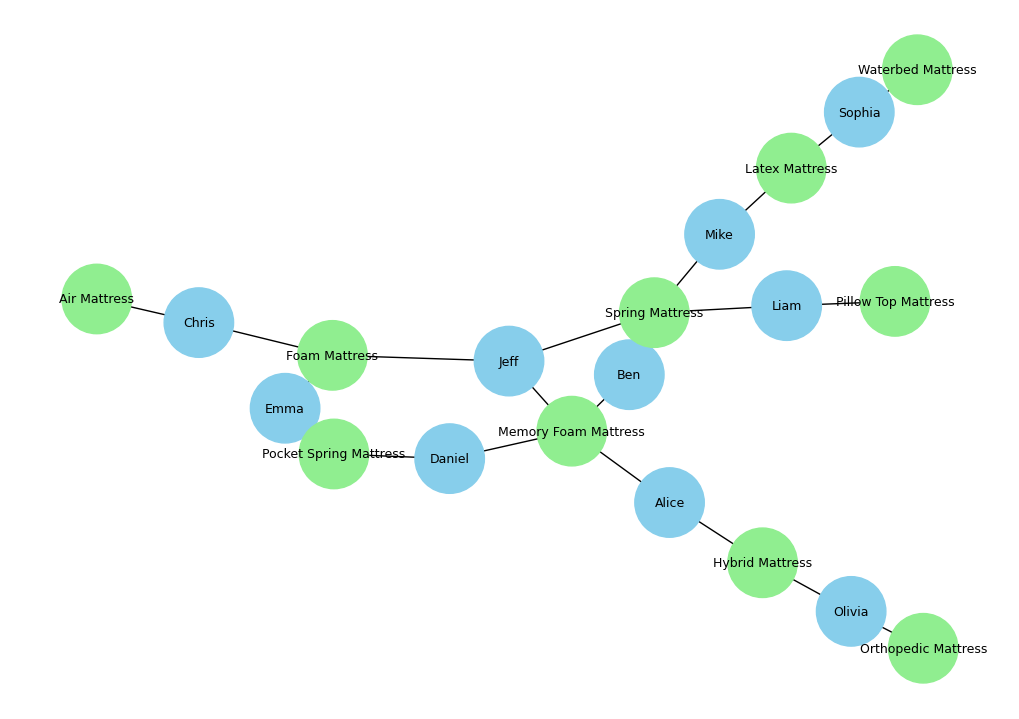

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

result = driver.execute_query(
    """
    MATCH (u:User)-[:PREFERS]->(m:MattressType)

    RETURN u.name AS user, m.name AS mattress_type
    """,
    database_=DATABASE
)

G = nx.Graph()

for record in result.records:
    G.add_node(record["user"], node_type="user")
    G.add_node(record["mattress_type"], node_type="mattress_type")
    G.add_edge(record["user"], record["mattress_type"])

node_colors = [
    "skyblue" if G.nodes[n]["node_type"] == "user" else "lightgreen"
    for n in G.nodes
]

plt.figure(figsize=(10, 7))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=2500,
    font_size=9
)

plt.show()

คำถามแรก <br>
1.ถามว่า Ben ชอบประเภทที่นอนอะไรบ้าง?

In [ ]:
result = driver.execute_query(
    """
    MATCH
        (u:User {name:'Ben'})
        -[:PREFERS]->
        (m:MattressType)

    RETURN m.name AS mattress_type
    """,
    database_=DATABASE
)

ben_mattress_types = [
    record["mattress_type"]
    for record in result.records
]

print(ben_mattress_types)

['Spring Mattress', 'Memory Foam Mattress']


ตรงนี้อธิบายได้ว่า MattressType ที่เชื่อมกับ Ben ด้วย PREFERS คือประเภทที่นอนที่ Ben ชอบ

คำถามที่ 2. หา User ที่ชอบประเภทที่นอนเหมือน Ben <br>
Ben ชอบ Spring Mattress, Memory Foam Mattress <br>
เราสามารถหาได้ว่าใครชอบประเภทที่นอนเหล่านี้เหมือนกัน

In [ ]:
result = driver.execute_query(
    """
    MATCH
        (me:User {name:'Ben'})
        -[:PREFERS]->
        (m:MattressType)
        <-[:PREFERS]-
        (other:User)

    RETURN
        m.name AS mattress_type,
        collect(other.name) AS similar_users

    ORDER BY mattress_type
    """,
    database_=DATABASE
)

for record in result.records:

    print("MattressType:", record["mattress_type"])

    for user in record["similar_users"]:
        print("  Similar user:", user)

MattressType: Memory Foam Mattress
  Similar user: Jeff
  Similar user: Daniel
  Similar user: Alice
MattressType: Spring Mattress
  Similar user: Jeff
  Similar user: Mike
  Similar user: Liam


**สร้าง Recommendation แบบง่ายด้วย Cypher**

```
แนวคิดคือ

Ben
 ↓  PREFERS
ประเภทที่นอนที่ Ben ชอบ
 ↓  PREFERS (ย้อนกลับ)
User ที่ชอบประเภทที่นอนเดียวกัน
 ↓  PREFERS
ประเภทที่นอนอื่นที่ User เหล่านั้นชอบ (และ Ben ยังไม่ได้เลือก)
 ↓
แนะนำให้ Ben
```

score = จำนวนเส้นทาง (path) ที่พาไปถึงประเภทที่นอนนั้น (เหมือน Counter ในเวอร์ชัน NetworkX)

In [ ]:
result = driver.execute_query(
    """
    MATCH
        (me:User {name:$user_name})
        -[:PREFERS]->
        (m:MattressType)
        <-[:PREFERS]-
        (other:User)
        -[:PREFERS]->
        (rec:MattressType)

    WHERE NOT EXISTS {

        MATCH
            (me)-[:PREFERS]->(rec)

    }

    RETURN
        rec.name AS recommendation,
        count(*) AS score,
        collect(DISTINCT other.name) AS recommended_by

    ORDER BY
        score DESC,
        recommendation
    """,

    user_name="Ben",
    database_=DATABASE
)

pd.DataFrame(
    [record.data() for record in result.records]
)

,recommendation,score,recommended_by
0,Foam Mattress,2,[Jeff]
1,Hybrid Mattress,1,[Alice]
2,Latex Mattress,1,[Mike]
3,Pillow Top Mattress,1,[Liam]
4,Pocket Spring Mattress,1,[Daniel]


ทำไม Foam Mattress ได้คะแนนสูงกว่า?

```
Ben ─ PREFERS ─ Spring Mattress ─────── Jeff ─ PREFERS ─ Foam Mattress
Ben ─ PREFERS ─ Memory Foam Mattress ── Jeff ─ PREFERS ─ Foam Mattress

Jeff ชอบที่นอนเหมือน Ben ถึง 2 ประเภท จึงมี 2 เส้นทางไปถึง Foam Mattress

score = 2
```

นำไปสร้างเป็นฟังก์ชัน

In [ ]:
def recommend_mattress_types(user_name):

    query = """
    MATCH
        (me:User {name:$user_name})
        -[:PREFERS]->
        (m:MattressType)
        <-[:PREFERS]-
        (other:User)
        -[:PREFERS]->
        (rec:MattressType)

    WHERE NOT EXISTS {

        MATCH
            (me)-[:PREFERS]->(rec)

    }

    RETURN
        rec.name AS recommendation,
        count(*) AS score

    ORDER BY
        score DESC,
        recommendation
    """

    result = driver.execute_query(
        query,
        user_name=user_name,
        database_=DATABASE
    )

    return pd.DataFrame(
        [record.data() for record in result.records]
    )

In [ ]:
#เรียกใช้งาน
recommend_mattress_types("Ben")

,recommendation,score
0,Foam Mattress,2
1,Hybrid Mattress,1
2,Latex Mattress,1
3,Pillow Top Mattress,1
4,Pocket Spring Mattress,1


In [ ]:
#เรียกใช้งาน
recommend_mattress_types("Mike")

,recommendation,score
0,Memory Foam Mattress,2
1,Foam Mattress,1
2,Pillow Top Mattress,1
3,Waterbed Mattress,1


In [ ]:
#เรียกใช้งาน
recommend_mattress_types("Jeff")

,recommendation,score
0,Pocket Spring Mattress,2
1,Air Mattress,1
2,Hybrid Mattress,1
3,Latex Mattress,1
4,Pillow Top Mattress,1


ฟังก์ชันดูประเภทที่นอนที่ User ชอบ

In [ ]:
def preferred_mattress_types(user_name):

    result = driver.execute_query(
        """
        MATCH
            (u:User {name:$user_name})
            -[:PREFERS]->
            (m:MattressType)

        RETURN m.name AS mattress_type

        ORDER BY mattress_type
        """,

        user_name=user_name,
        database_=DATABASE
    )

    return [record["mattress_type"] for record in result.records]

In [ ]:
preferred_mattress_types("Ben")

['Memory Foam Mattress', 'Spring Mattress']

ประเภทที่นอนไหนได้รับความนิยมมากที่สุด

In [ ]:
result = driver.execute_query(
    """
    MATCH
        (:User)
        -[:PREFERS]->
        (m:MattressType)

    RETURN
        m.name AS mattress_type,
        count(*) AS total_users

    ORDER BY total_users DESC, mattress_type
    """,
    database_=DATABASE
)

pd.DataFrame(
    [record.data() for record in result.records]
)

,mattress_type,total_users
0,Memory Foam Mattress,4
1,Spring Mattress,4
2,Foam Mattress,3
3,Hybrid Mattress,2
4,Latex Mattress,2
5,Pocket Spring Mattress,2
6,Air Mattress,1
7,Orthopedic Mattress,1
8,Pillow Top Mattress,1
9,Waterbed Mattress,1


ดู Graph ใน Neo4j Aura

หลังจากรันข้อมูลจาก Colab แล้ว ให้กลับไปที่ Neo4j Aura → Query แล้วรัน

```
MATCH (u:User)-[r:PREFERS]->(m:MattressType)
RETURN u, r, m
```

หรือดูเฉพาะเส้นทางการแนะนำของ Ben

```
MATCH p = (me:User {name:'Ben'})-[:PREFERS]->(:MattressType)<-[:PREFERS]-(:User)-[:PREFERS]->(:MattressType)
RETURN p
```

In [ ]:
#ตรวจจำนวน Node และ Relationship ของระบบแนะนำที่นอน
result = driver.execute_query(
    """
    MATCH (n)

    WHERE n:User OR n:MattressType

    OPTIONAL MATCH (n)-[r:PREFERS]->()

    RETURN
        count(DISTINCT n) AS nodes,
        count(r) AS relationships
    """,
    database_=DATABASE
)

print(result.records[0].data())

{'nodes': 20, 'relationships': 21}


Recommender System แบบ Graph ไม่ได้มองเพียงว่า “ประเภทที่นอนไหนดี” แต่ดูว่า “ผู้ใช้คนนี้เชื่อมโยงกับผู้ใช้และประเภทที่นอนอื่นอย่างไร”

In [ ]:
#ปิด Connection เมื่อเรียนเสร็จ

driver.close()

print("Neo4j connection closed")

Neo4j connection closed
